In [1]:
import torch
import torchvision
from torch import nn
import os
from copy import deepcopy
import wandb
import numpy
import matplotlib.pyplot as plt
import jupyter_client
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
jupyter_client.write_connection_file()
%connect_info
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vilmos/.netrc.


{"key":"b567563f-00bb-4bfa-96cd-813672e14be7","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9005,"control_port":9006,"shell_port":9007,"stdin_port":9008,"iopub_port":9009,"kernel_name":"python3128jvsc74a57bd0ad935c8efeede59033570a116aa1708a3cd8f1e8834f3daeba0d133100277ff5"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1001/jupyter/runtime/kernel-v3ec4581f706b3d9ded8767893856e63ed03bc23d1.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


wandb: Currently logged in as: v-vilmos10 (v-vilmos10-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Batch Normalization

In [ ]:
from irwl1.config import DEVICE, LEARNING_RATE, MODE, BATCH_SIZE, PATIENCE, LAMBDA_REG, REG_TYPE, EPOCHS, EPSILON, K
from irwl1.data import fetch_fmnist, load_to_memory
from irwl1.model import LeNet, oriLeNet

model = LeNet()
original = oriLeNet()

train_loader, val_loader, test_loader = fetch_fmnist()
train_image_tensor, train_label_tensor = load_to_memory(train_loader) 
val_image_tensor, val_label_tensor = load_to_memory(val_loader) 
test_image_tensor, test_label_tensor = load_to_memory(test_loader) 

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training

### Retraining

In [26]:
def prune_layer(layer):
  if type(layer) in [nn.Conv2d]:
    weight = layer.weight
    filter, depth, height, width = weight.shape
    with torch.no_grad():
      match(mode):
        case "weight-wise":
          weight_amplitude = torch.abs(weight)
          threshold = torch.quantile(weight_amplitude, q=compress_ratio/100)
          mask = torch.tensor(weight_amplitude < threshold, dtype=torch.float32)
          weight[weight_amplitude < threshold] = torch.tensor(0.0, dtype=torch.float32, device=device, requires_grad=False)
        case "kernel-wise":
          kernel_amplitude = weight.pow(2).sum(dim=(2, 3)).sqrt()
          threshold = torch.quantile(kernel_amplitude, q=compress_ratio/100)
          mask = torch.tensor(kernel_amplitude < threshold, dtype=torch.float32)
          weight[kernel_amplitude < threshold] = torch.zeros(height, width, dtype=torch.float32, device=device, requires_grad=False)

        case "channel-wise":
          channel_amplitude = weight.pow(2).sum(dim=(1, 2, 3)).sqrt()
          threshold = torch.quantile(channel_amplitude, q=compress_ratio/100)
          mask = torch.tensor(channel_amplitude < threshold, dtype=torch.float32)
          weight[channel_amplitude < threshold] = torch.zeros(depth, height, width, dtype=torch.float32, device=device, requires_grad=False)

  return mask


In [28]:
reg_type = "RWL1"
learning_rate = learning_rate / 2 # using smaller learning rate for retraining
patience=10

def retrain():
    current_patience = patience
    best_params = None
    train_size = train_image_tensor.shape[0]
    best_val_loss = float('inf')
    num_batches = round(train_image_tensor.shape[0] / batch_size)
    for epoch in range(num_epochs/2):
        total_train_loss = 0
        indices = torch.randperm(train_size)
        train_image_tensor = train_image_tensor[indices]
        train_label_tensor = train_label_tensor[indices]
        for i in range(0, train_size, batch_size):
            optimizer.zero_grad(set_to_none=True)
            outputs = model(train_image_tensor[i:i+batch_size])
            loss = criterion(input=outputs, target=train_label_tensor[i:i+batch_size])
            total_train_loss += loss.item()
            loss.backward()

            with torch.no_grad():
                model.conv1.weight.mul_(model.conv1_mask)
                model.conv2.weight.mul_(model.conv2_mask)

            optimizer.step()

            with torch.no_grad():
                model.conv1.weight.mul_(model.conv1_mask)
                model.conv2.weight.mul_(model.conv2_mask)

        train_loss = total_train_loss / num_batches
        current_val_loss, val_acc = validate()
        run.log({"train/loss": train_loss, "val/loss": current_val_loss, "val/acc": val_acc})

        if best_val_loss > current_val_loss:
            best_val_loss = current_val_loss
            best_params = deepcopy(model.state_dict)
            current_patience = patience
        else:
            current_patience -= 1

        if current_patience == 0:
            run.finish()
            break

    if current_patience != 0:
        run.finish()

    if reg_type == "L0":
        torch.save(best_params, f=f"./models/{reg_type}/state_dict_{mode}_{round(compress_ratio, 3)}.pth")
    elif reg_type == "L1":
        torch.save(best_params, f=f"./models/{reg_type}/state_dict_{mode}_{round(lambda_reg, 3)}.pth")
    else:
        torch.save(best_params, f=f"./models/{reg_type}/state_dict_{mode}_lambda{lambda_reg}_K{K}_eps{epsilon}.pth")


    
        


In [34]:
reg_type = "RWL1"
for K in [4, 8, 16]:
  torch.manual_seed(40)
  model = LeNet()   # init with same random weights
  model.to(device)
  model.apply(L1_penalty_init)
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  model = train()

  model.conv1_mask = prune_layer(model.conv1)
  model.conv2_mask = prune_layer(model.conv2)
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  retrain() # it saves the retrained model state dict







wandb: ERROR The nbformat package was not found. It is required to save notebook history.


UnboundLocalError: cannot access local variable 'train_image_tensor' where it is not associated with a value

# Results

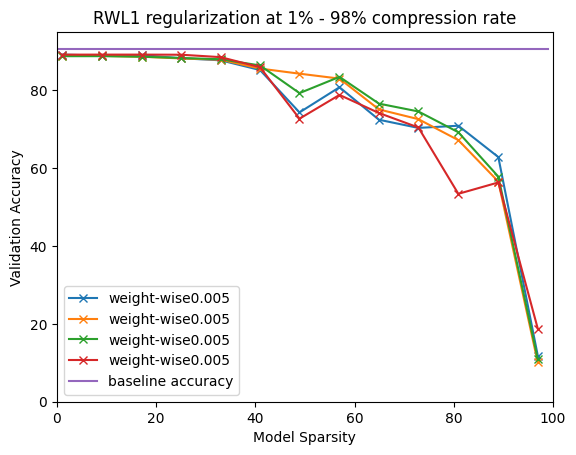

In [ ]:
import pandas
def eval():
  model.apply(prune_layer) # the model prunes itself
  avg_test_loss, test_acc = test()
  sparsity = calculate_real_sparsity()
  return avg_test_loss, test_acc, sparsity


test_loader = torch.utils.data.DataLoader(fmnist_test, batch_size=64, shuffle=False)
criterion = nn.CrossEntropyLoss()
model = LeNet()
model.to(device)

lambda_reg = 0.005
update_interval = 1

fig, ax = plt.subplots()

mode = "weight-wise"
for epsilon in [0.001, 0.0001, 0.00001, 0.000001]:
      params = torch.load(f"./drive/MyDrive/DL/{reg_type}/state_dict_{mode}_lambda{lambda_reg}_int{update_interval}_eps{epsilon}.pth", map_location=device)
      accuracies, sparsities, compress_ratios, modes, lambdas, epsilons = [], [], [], [], [], []
      for compress_ratio in range(1, 98, 8):
        model.load_state_dict(params)
        _, acc, spar = eval()
        accuracies.append(acc)
        sparsities.append(spar)
        compress_ratios.append(compress_ratio)
        modes.append(mode)
        lambdas.append(lambda_reg)
        epsilons.append(epsilon)

      ax.plot(sparsities,accuracies, label=mode+f"{lambda_reg}", marker="x")
      rows = {"mode": modes, "spar": sparsities, "acc": accuracies, "lambda": lambdas, "ratio": compress_ratios, "epsilon": epsilons}
      df_new = pandas.DataFrame(rows)
      df = pandas.read_csv(f"./drive/MyDrive/DL/{reg_type}/results.csv")
      df = pandas.concat([df, df_new])
      df.to_csv(f"./drive/MyDrive/DL/{reg_type}/results.csv", index=False)

plt.plot( [0.5, 99], [90.77]*2, label="baseline accuracy")
plt.xlim(0,100)
plt.ylim(0, 95)
plt.ylabel("Validation Accuracy")
plt.xlabel("Model Sparsity")
plt.title(f"{reg_type} regularization at 1% - 98% compression rate")
plt.legend()
plt.show()

### Fetch results

In [ ]:
import pandas as pd
import re
api = wandb.Api()

runs = api.runs("v-vilmos10-/fmnist_lenet")


In [ ]:
# finding L0 at different groups with diff compress ratio ()
l0_runs = {}
for group in ["WEIGHT", "KERNEL", "CHANNEL"]:
    l0_runs[group] = [runs[i] for i in range(len(runs)) if re.search(f"L0[_-]{group}.*RATIO", str(runs[i].name).upper()) != None]

# finding L1 at different lambdas
l1_runs = {}
for group in ["WEIGHT", "KERNEL", "CHANNEL"]:
  l1_runs[group] = [runs[i] for i in range(len(runs)) if re.search(f"L1.{group}.*LAMBDA.*", str(runs[i].name).upper()) != None]

# finding WL1 at different lambdas


In [ ]:
len(l0_runs["KERNEL"])

10

In [ ]:
import numpy
# finding best val/loss and other metrics
def evaluate_run(run):
  df = run.history(100)
  val_acc = df.loc[df["val/loss"].argmin(), "val/acc"]
  sparsity = df.loc[df["val/loss"].argmin(), "sparsity"]

  return numpy.array([val_acc, sparsity])


l0_metrics, l1_metrics = {}, {}
for group in ["WEIGHT", "KERNEL", "CHANNEL"]:
  l0_metrics[group] = numpy.array([evaluate_run(l0_runs[group][i]) for i in range(len(l0_runs[group]))])
  l1_metrics[group] = numpy.array([evaluate_run(l1_runs[group][i]) for i in range(len(l1_runs[group]))])



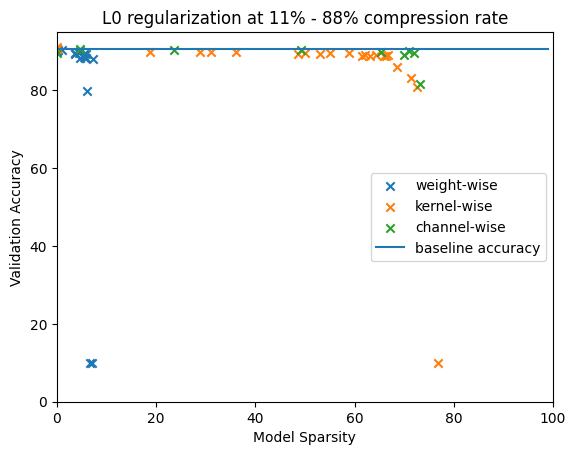

In [ ]:
fig, ax = plt.subplots()
for group in ["WEIGHT", "KERNEL", "CHANNEL"]:
    ax.scatter(l1_metrics[group][:,1],l1_metrics[group][:, 0], label=group.lower()+"-wise", marker="x")


plt.plot( [0.5, 99], [90.77]*2, label="baseline accuracy")
plt.xlim(0,100)
plt.ylim(0, 95)
plt.ylabel("Validation Accuracy")
plt.xlabel("Model Sparsity")
plt.title("L0 regularization at 11% - 88% compression rate")
plt.legend()
plt.show()


### L0 with PGM

| W-group | Comp. Rate | Val. Acc. | Sparsity |
| ------- | -----------| --------- | -------- |
| Element | 33% | 89% | 45% |
| | 77% | 85.5% | 83% |
| Kernel | 33% | 89.93% | 36% |
| | 77% | 87% | 77% |
| Channel | 33% | 89% | 37% |
| | 77% | 81.68% | 74.5% |

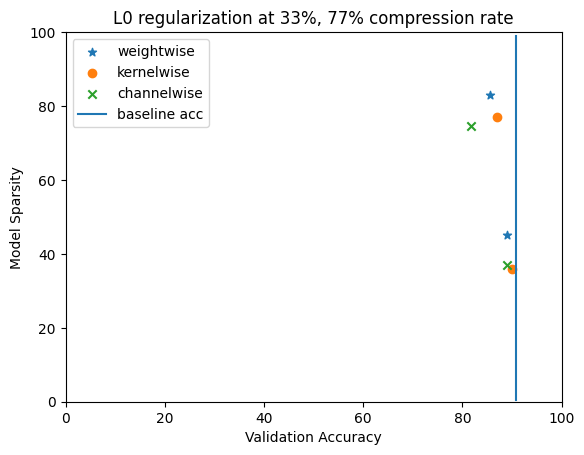

In [ ]:
import matplotlib.pyplot as plt

weightwise = {"val_acc": [89, 85.55], "sparsity": [45, 83]}
kernelwise = {"val_acc": [89.93, 87], "sparsity": [36, 77]}
channelwise = {"val_acc": [89, 81.68], "sparsity": [37, 74.5]}


plt.scatter(weightwise["val_acc"], weightwise["sparsity"], marker="*", label="weightwise")
plt.scatter(kernelwise["val_acc"], kernelwise["sparsity"], marker="o", label="kernelwise")
plt.scatter(channelwise["val_acc"], channelwise["sparsity"], marker="x", label="channelwise")
plt.plot([90.77]*2, [0.5, 99], label="baseline acc")

plt.xlim(0,100)
plt.ylim(0, 100)
plt.xlabel("Validation Accuracy")
plt.ylabel("Model Sparsity")
plt.title("L0 regularization at 33%, 77% compression rate")
plt.legend()


plt.show()

### L1 regularization

In [ ]:
weightwise = {"val_acc": [89, 85.55], "sparsity": [45, 83]}
kernelwise = {"val_acc": [89.93, 87], "sparsity": [36, 77]}
channelwise = {"val_acc": [89, 81.68], "sparsity": [37, 74.5]}


plt.scatter(weightwise["val_acc"], weightwise["sparsity"], marker="*", label="weightwise")
plt.scatter(kernelwise["val_acc"], kernelwise["sparsity"], marker="o", label="kernelwise")
plt.scatter(channelwise["val_acc"], channelwise["sparsity"], marker="x", label="channelwise")
plt.plot([90.77]*2, [0.5, 99], label="baseline acc")

plt.xlim(0,100)
plt.ylim(0, 100)
plt.xlabel("Validation Accuracy")
plt.ylabel("Model Sparsity")
plt.title("L0 regularization at 33%, 77% compression rate")
plt.legend()


plt.show()